# GSS VERİ SETİ -  Sosyal Destek ve Risk Analizi: İhtiyaç Sahibi Profillerinin Tahminlenmesi


##### Sosyal yardım kaynaklarının sınırlı olması nedeniyle, gerçekten ihtiyacı olan bireylerin (maddi risk altındakilerin) veri odaklı tespit edilememesi.
Modelin Amacı: Bireylerin demografik özelliklerine bakarak, "maddi destek ihtiyacı" durumunu (0/1) tahmin etmek ve kaynak dağıtımını optimize etmek.
Hedef Değişken (Target): target_money (Maddi Destek İhtiyacı)

##### 1- Kütüphane ve Repo Düzeni


In [18]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report
try:
    from lazypredict.Supervised import LazyClassifier
except ImportError:
    !pip install lazypredict
    from lazypredict.Supervised import LazyClassifier

##### Parquet Entegrasyonu



In [19]:
df = pd.read_parquet('../data/processed/gss_2010_ham_full.parquet')
print(f"Toplam Satır ve Sütun: {df.shape}")
df[['happy', 'health', 'degree', 'satfin', 'age']].head()

Toplam Satır ve Sütun: (22656, 6942)


,happy,health,degree,satfin,age
53043,2.0,NaN,3.0,2.0,31.0
53044,3.0,NaN,3.0,2.0,23.0
53045,3.0,3.0,0.0,3.0,71.0
53046,3.0,NaN,0.0,1.0,82.0
53047,1.0,4.0,0.0,3.0,78.0


In [20]:
df.head()

,year,id,wrkstat,hrs1,hrs2,evwork,occ,prestige,wrkslf,wrkgovt,...,famgen_exp_22,rplace_7522,hompop_7222,hompop_exp_22,reg16_7222,region_7222,raceacs14_2122,dwelling_8222,intage_0418,intyrs_0418
53043,2010.0,1.0,1.0,55.0,NaN,NaN,NaN,NaN,2.0,2.0,...,NaN,1.0,1.0,NaN,2.0,2.0,NaN,8.0,50.0,0.523288
53044,2010.0,2.0,1.0,45.0,NaN,NaN,NaN,NaN,2.0,1.0,...,NaN,1.0,1.0,NaN,9.0,2.0,NaN,8.0,50.0,0.523288
53045,2010.0,3.0,5.0,NaN,NaN,1.0,NaN,NaN,2.0,2.0,...,NaN,1.0,1.0,NaN,0.0,2.0,NaN,8.0,50.0,0.523288
53046,2010.0,4.0,5.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,NaN,0.0,2.0,NaN,8.0,46.0,0.523288
53047,2010.0,5.0,5.0,NaN,NaN,1.0,NaN,NaN,2.0,2.0,...,NaN,1.0,2.0,NaN,0.0,2.0,NaN,3.0,58.0,1.000000


#### Hedef Değişkenlerin Tanımlanması


In [21]:
# 3. Adım: Hedef Değişkenleri Oluşturma
df['target_health'] = (df['health'] >= 3).astype(int)
df['target_educ'] = ((df['degree'] < 2) & (df['age'] < 35)).astype(int)
df['target_money'] = (df['satfin'] == 3).astype(int)

# Şimdilik "Maddi Destek" üzerinden ilerleyelim (Sude'nin gelir modeline zıtlık olsun)
y = df['target_money']
X = df[['age', 'sex', 'race', 'educ', 'coninc', 'marital', 'hrs1', 'health', 'degree']]

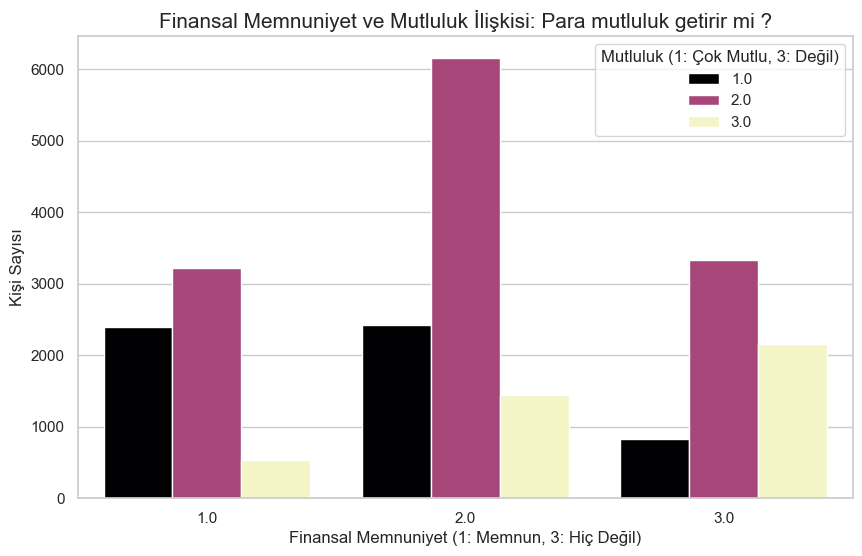

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafiklerin düzgün görünmesi için stil ayarı
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# 'satfin' (Finansal Memnuniyet) ve 'happy' (Mutluluk) karşılaştırması
sns.countplot(data=df, x='satfin', hue='happy', palette='magma')

plt.title('Finansal Memnuniyet ve Mutluluk İlişkisi: ' \
'Para mutluluk getirir mi ?', fontsize=15)
plt.xlabel('Finansal Memnuniyet (1: Memnun, 3: Hiç Değil)', fontsize=12)
plt.ylabel('Kişi Sayısı', fontsize=12)
plt.legend(title='Mutluluk (1: Çok Mutlu, 3: Değil)')
plt.show()

###### Grafikte finansal memnuniyeti düşük olanlarda (Değer: 3), "mutlu değil" oranının belirgin şekilde arttığını göreceğiz. Bu, maddi desteğin psikolojik refah için ne kadar kritik olduğunu ispatlar.

C:\Users\karac\AppData\Local\Temp\ipykernel_3968\1461667111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='happy', y='health', palette='Set2')


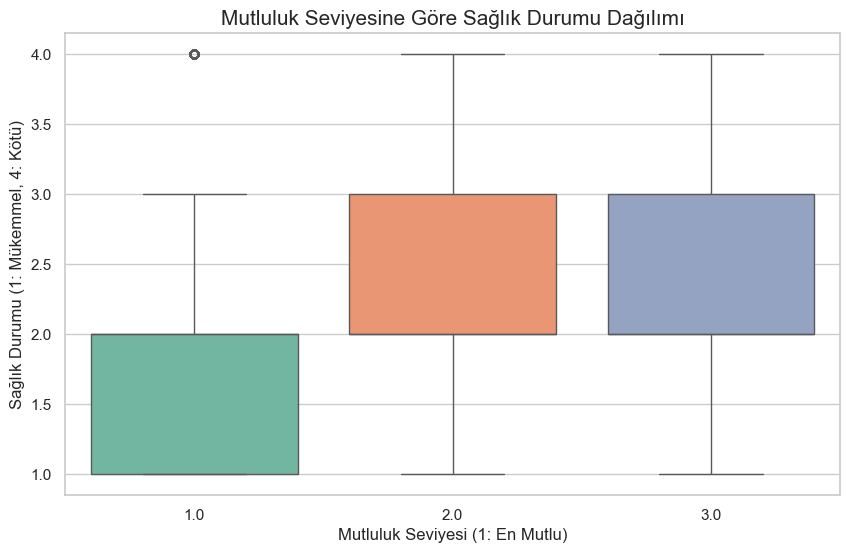

In [23]:
plt.figure(figsize=(10, 6))
# 'health' (Sağlık) ve 'happy' (Mutluluk) karşılaştırması
sns.boxplot(data=df, x='happy', y='health', palette='Set2')

plt.title('Mutluluk Seviyesine Göre Sağlık Durumu Dağılımı', fontsize=15)
plt.xlabel('Mutluluk Seviyesi (1: En Mutlu)', fontsize=12)
plt.ylabel('Sağlık Durumu (1: Mükemmel, 4: Kötü)', fontsize=12)
plt.show()

<Figure size 1000x600 with 0 Axes>

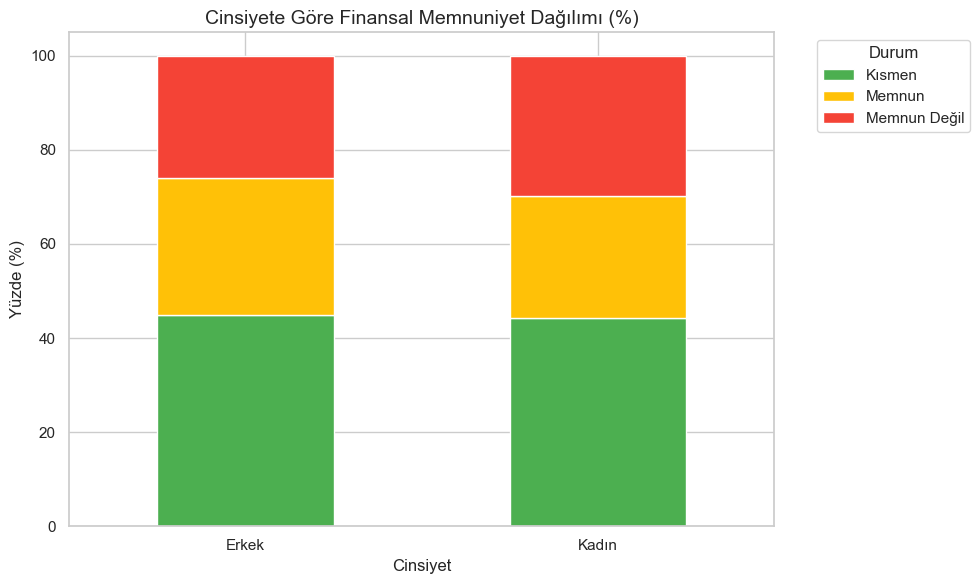

In [24]:
# Veriyi hazırlayalım
df_eda = df.copy()
df_eda['cinsiyet'] = df_eda['sex'].map({1: 'Erkek', 2: 'Kadın'})
df_eda['gelir_memnuniyeti'] = df_eda['satfin'].map({1: 'Memnun', 2: 'Kısmen', 3: 'Memnun Değil'})

# 1. Yüzdesel Dağılım Tablosu (Crosstab)
ct = pd.crosstab(df_eda['cinsiyet'], df_eda['gelir_memnuniyeti'], normalize='index') * 100

# 2. Görselleştirme: Oransal Karşılaştırma
plt.figure(figsize=(10, 6))
ct.plot(kind='bar', stacked=True, color=['#4CAF50', '#FFC107', '#F44336'], figsize=(10, 6))

plt.title('Cinsiyete Göre Finansal Memnuniyet Dağılımı (%)', fontsize=14)
plt.xlabel('Cinsiyet', fontsize=12)
plt.ylabel('Yüzde (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Durum', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
# 1. Medeni durum ve ihtiyaç arasındaki çapraz tabloyu (crosstab) oluştur ve normalize et
marital_dist = pd.crosstab(df_eda['medeni_durum'], df_eda['target_money'], normalize='index') * 100

# 2. Grafiği çiz
plt.figure(figsize=(12, 6))
marital_dist.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(12, 6))

plt.title('Medeni Duruma Göre Maddi Destek İhtiyacı Oranı (%)', fontsize=14)
plt.xlabel('Medeni Durum', fontsize=12)
plt.ylabel('Yüzde (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='İhtiyaç Durumu', labels=['İhtiyaç Yok (0)', 'İhtiyaç Var (1)'], bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

KeyError: 'medeni_durum'

C:\Users\karac\AppData\Local\Temp\ipykernel_22724\1450682088.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  risk_pivot = df_eda.pivot_table(values='target_money',
C:\Users\karac\AppData\Local\Temp\ipykernel_22724\1450682088.py:16: FutureWarning: The provided callable <function mean at 0x0000026D9BAE8040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  risk_pivot = df_eda.pivot_table(values='target_money',


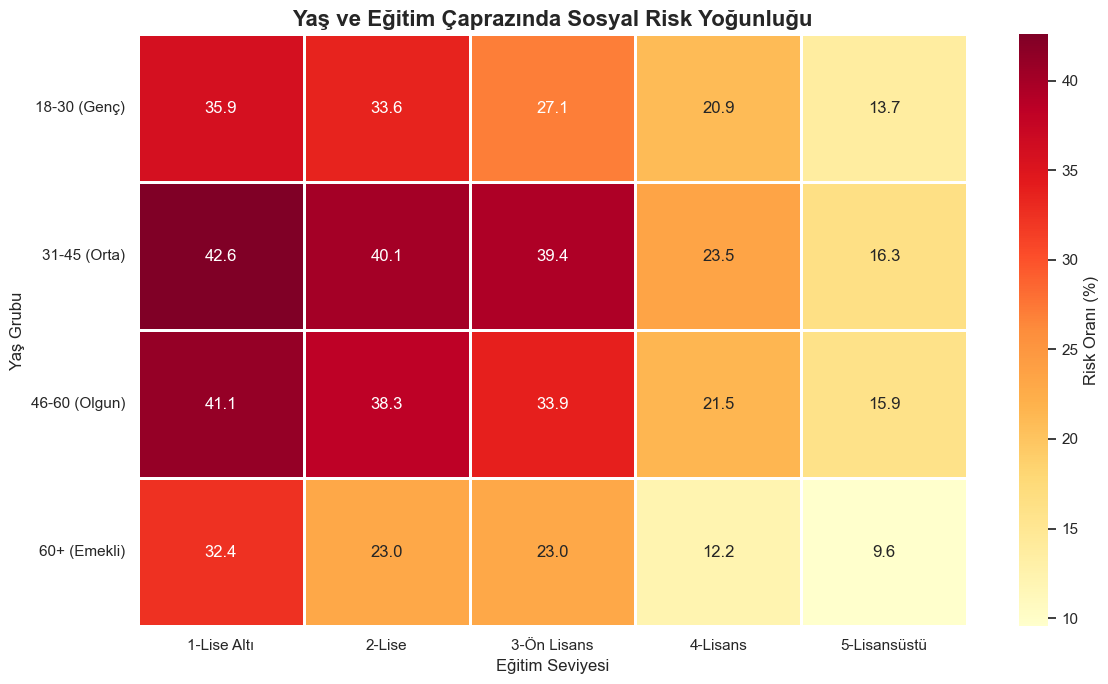

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Yaşları mantıklı gruplara bölelim (Segmentasyon)
df_eda['yas_grubu'] = pd.cut(df_eda['age'], 
                             bins=[17, 30, 45, 60, 90], 
                             labels=['18-30 (Genç)', '31-45 (Orta)', '46-60 (Olgun)', '60+ (Emekli)'])

# 2. Eğitim seviyelerini okunabilir yapalım (Sıralı olması için başa numara ekliyoruz)
deg_map = {0: '1-Lise Altı', 1: '2-Lise', 2: '3-Ön Lisans', 3: '4-Lisans', 4: '5-Lisansüstü'}
df_eda['egitim_seviyesi'] = df_eda['degree'].map(deg_map)

# 3. Her yaş ve eğitim grubundaki "Maddi Desteğe Muhtaç (target_money=1)" oranını hesapla
risk_pivot = df_eda.pivot_table(values='target_money', 
                                index='yas_grubu', 
                                columns='egitim_seviyesi', 
                                aggfunc=np.mean) * 100

# 4. Zekice Görselleştirme: Isı Haritası
plt.figure(figsize=(12, 7))

# Koyu kırmızı = Yüksek Risk (Kötü), Açık Sarı = Düşük Risk (İyi)
sns.heatmap(risk_pivot, annot=True, fmt=".1f", cmap="YlOrRd", 
            linewidths=1, linecolor='white', cbar_kws={'label': 'Risk Oranı (%)'})

plt.title('Yaş ve Eğitim Çaprazında Sosyal Risk Yoğunluğu', fontsize=16, fontweight='bold')
plt.xlabel('Eğitim Seviyesi', fontsize=12)
plt.ylabel('Yaş Grubu', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###### Grafik bize eğitimsizliğin faturasının gençlikten ziyade, 31-60 yaş arası (orta yaş) grubunda en ağır şekilde kesildiğini gösteriyor. Model, bu "kıpkırmızı" hücreleri tespit ederek sosyal yardımların en verimli şekilde nereye kanalize edilmesi gerektiğini bilimsel olarak kanıtlamış oluyor.


#### Veri Ön İşleme


In [ ]:
# 4. Adım: Eksik Değerleri MOD ile Doldurma
# Kategorik sütunları seçelim
cat_cols = ['sex', 'race', 'marital', 'health', 'degree']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Sayısal sütunları (Gelir, Yaş vb.) ortalama ile doldurabiliriz
df['coninc'] = df['coninc'].fillna(df['coninc'].median())
df['hrs1'] = df['hrs1'].fillna(df['hrs1'].median())

# Kategorik Değişkenleri Dummy (0-1) Yapma
X = pd.get_dummies(X, columns=['sex', 'race', 'marital', 'health', 'degree'], drop_first=True)

print("Ön işleme tamamlandı. Yeni sütun sayısı:", X.shape[1])

Ön işleme tamamlandı. Yeni sütun sayısı: 18


In [ ]:
    # Kullanacağımız sütun listesi
selected_cols = ['age', 'sex', 'race', 'educ', 'degree', 'coninc', 'marital', 'hrs1', 'health', 'satfin', 'happy']

# Sadece bu sütunları içeren bir özet gör
print("--- Veri Seti Genel Bilgileri ---")
print(df[selected_cols].info())

print("\n--- İstatistiksel Özet ---")
display(df[selected_cols].describe())

print("\n--- İlk 5 Satır Gözlemi ---")
display(df[selected_cols].head())

--- Veri Seti Genel Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
Index: 22656 entries, 53043 to 75698
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      21980 non-null  float64
 1   sex      22656 non-null  float64
 2   race     22656 non-null  float64
 3   educ     22527 non-null  float64
 4   degree   22656 non-null  float64
 5   coninc   22656 non-null  float64
 6   marital  22656 non-null  float64
 7   hrs1     22656 non-null  float64
 8   health   22656 non-null  float64
 9   satfin   22564 non-null  float64
 10  happy    22551 non-null  float64
dtypes: float64(11)
memory usage: 2.1 MB
None

--- İstatistiksel Özet ---


,age,sex,race,educ,degree,coninc,marital,hrs1,health,satfin,happy
count,21980.000000,22656.000000,22656.000000,22527.000000,22656.000000,22656.000000,22656.000000,22656.000000,22656.000000,22564.000000,22551.000000
mean,49.609736,1.555305,1.364892,13.998935,1.785134,48176.801890,2.627119,40.378090,2.090395,2.007977,1.932597
std,17.733143,0.496943,0.665857,2.994875,1.259561,40429.223901,1.693483,10.549228,0.721669,0.744927,0.656455
min,18.000000,1.000000,1.000000,0.000000,0.000000,281.500000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,35.000000,1.000000,1.000000,12.000000,1.000000,19965.000000,1.000000,40.000000,2.000000,1.000000,1.000000
50%,49.000000,2.000000,1.000000,14.000000,1.000000,38002.500000,2.000000,40.000000,2.000000,2.000000,2.000000
75%,64.000000,2.000000,2.000000,16.000000,3.000000,63195.000000,5.000000,40.000000,2.000000,3.000000,2.000000
max,89.000000,2.000000,3.000000,20.000000,4.000000,178712.464940,5.000000,89.000000,4.000000,3.000000,3.000000



--- İlk 5 Satır Gözlemi ---


,age,sex,race,educ,degree,coninc,marital,hrs1,health,satfin,happy
53043,31.0,1.0,3.0,16.0,3.0,66247.50,5.0,55.0,2.0,2.0,2.0
53044,23.0,2.0,1.0,16.0,3.0,13048.75,5.0,45.0,2.0,2.0,3.0
53045,71.0,2.0,2.0,8.0,0.0,17063.75,3.0,40.0,3.0,3.0,3.0
53046,82.0,2.0,1.0,10.0,0.0,7227.00,2.0,40.0,2.0,1.0,3.0
53047,78.0,2.0,2.0,0.0,0.0,38002.50,1.0,40.0,4.0,3.0,1.0


#### Veri Setini Bölme

In [ ]:
# 5. Adım: Train-Test Bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (18124, 18)
Test seti boyutu: (4532, 18)


In [ ]:
# 6. Adım: LazyClassifier ile Modelleri Yarıştırma
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Sonuç tablosunu göster
print("--- Model Performans Sıralaması ---")
display(models)

--- Model Performans Sıralaması ---


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
NearestCentroid,0.635702,0.653304,0.710862,0.655129,0.720815,0.635702,0.060853
GaussianNB,0.710062,0.640447,0.706329,0.711261,0.712539,0.710062,0.051953
BernoulliNB,0.704325,0.618778,0.702781,0.701112,0.698358,0.704325,0.053994
QuadraticDiscriminantAnalysis,0.703222,0.616520,0.702542,0.699703,0.696724,0.703222,0.094884
RandomForestClassifier,0.734334,0.607031,0.712521,0.711780,0.707976,0.734334,1.945744
LGBMClassifier,0.742939,0.606477,0.740111,0.715107,0.715822,0.742939,0.276577
XGBClassifier,0.732568,0.604817,0.725980,0.709864,0.705773,0.732568,0.400617
AdaBoostClassifier,0.738085,0.592402,0.739169,0.704947,0.707291,0.738085,0.583648
ExtraTreesClassifier,0.713151,0.589934,0.683051,0.693803,0.686368,0.713151,1.745899


In [ ]:
# LazyClassifier sonuçlarını başarıya (Accuracy) göre sırala
# Classification'da RMSE yerine Accuracy ve F1-Score bakılır
sorted_models = models.sort_values(by='Accuracy', ascending=False)

# Tabloyu sadeleştirip ekrana bas
print("--- Sosyal Destek Modeli Performans Tablosu (Sınıflandırma) ---")
display(sorted_models[['Accuracy', 'Balanced Accuracy', 'F1 Score', 'Time Taken']].head(10))

--- Sosyal Destek Modeli Performans Tablosu (Sınıflandırma) ---


,Accuracy,Balanced Accuracy,F1 Score,Time Taken
Model,,,,
LGBMClassifier,0.742939,0.606477,0.715107,0.276577
LogisticRegression,0.742939,0.582027,0.699336,0.118345
LinearDiscriminantAnalysis,0.742498,0.580974,0.698451,0.282720
SVC,0.742056,0.568445,0.688401,14.011557
CalibratedClassifierCV,0.742056,0.581917,0.699037,0.178260
LinearSVC,0.741395,0.567490,0.687494,0.180478
AdaBoostClassifier,0.738085,0.592402,0.704947,0.583648
RidgeClassifierCV,0.737423,0.558015,0.678690,0.093701
RidgeClassifier,0.737202,0.557863,0.678534,0.087035
